# Runtime scaling of SciPy L-BFGS-B

This notebook investigates a possible runtime-scaling issue in `scipy.optimize.minimize(method="L-BFGS-B")`.

The question is deliberately about wall-clock overhead, not which method reaches the smallest objective value.


## Reproduction protocol

All solvers receive an analytic gradient, use L-BFGS memory `m=10`, run without callbacks, and have convergence tolerances disabled as far as their public interfaces allow.

In [ ]:
import json
import os
import platform
import shutil
import subprocess
import sys
import time
from contextlib import nullcontext
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from qnlab.parameter import LineParameter, NTRQNParameter
from qnlab.problem.base import BaseProblem
from qnlab.problem.ill_quadratic import IllQuadraticProblem
from qnlab.solver.qn_line import qn_line
from qnlab.solver.qn_ntrqn import qn_ntrqn
from qnlab.util.method import Method
from scipy.optimize import minimize
from threadpoolctl import threadpool_info, threadpool_limits

ENVIRONMENT = {
    "python": sys.version.replace("\n", " "),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "scipy_git_revision": scipy.version.git_revision,
    "platform": platform.platform(),
    "processor": platform.processor() or "not reported",
    "cpu_count": os.cpu_count(),
}
pd.Series(ENVIRONMENT, name="value").to_frame()

,value
python,"3.12.11 (main, Sep 18 2025, 19:45:51) [MSC v.1..."
numpy,2.2.6
scipy,1.16.1
scipy_git_revision,0cf8e9541b1a2457992bf4ec2c0c669da373e497
platform,Windows-11-10.0.26200-SP0
processor,"Intel64 Family 6 Model 186 Stepping 2, Genuine..."
cpu_count,16


## Problem definition

We used the following two test problems to investigate the issue.

### Problem 1: A smooth zero-chain problem

The first one is the famous "zero-chain" problem. For dimension $n$, define

$$
f(x)=\frac12 x_1^2-x_1+\frac12\sum_{i=1}^{n-1}(x_i-x_{i+1})^2.
$$

This is a strictly convex, ill-conditioned quadratic with minimizer $x^*=(1,\ldots,1)$.
Taking `dimension > max_iterations` prevents the algorithm from simply exhausting the chain before an iteration-cap measurement.
Both the function and gradient below cost $\mathcal{O}(n)$ and allocate only a few vectors.


In [2]:
class ZeroChainQuadratic(BaseProblem):
    def __init__(self, n: int):
        super().__init__(name="ZeroChainQuadratic", n=n, x0=np.zeros(n))
        self.x_opt = np.ones(n)

    def _f(self, x: np.ndarray) -> np.float64:
        differences = x[:-1] - x[1:]
        return np.float64(0.5 * x[0] ** 2 - x[0] + 0.5 * differences @ differences)

    def _g(self, x: np.ndarray) -> np.ndarray:
        differences = x[:-1] - x[1:]
        gradient = np.zeros_like(x)
        gradient[0] = x[0] - 1.0
        gradient[:-1] += differences
        gradient[1:] -= differences
        return gradient


# Sanity checks for the formula and zero-chain structure.
_problem = ZeroChainQuadratic(8)
assert np.isclose(_problem.f(_problem.x_opt, count=False), -0.5)
assert np.allclose(_problem.g(_problem.x_opt, count=False), 0.0)
assert np.array_equal(np.flatnonzero(_problem.g(_problem.x0, count=False)), [0])

## Problem 2: A diagonal quadratic problem

The second problem is a diagonal quadratic, which is close to `script/computation_time.py`.

The diagonal quadratic is

$$
f(x)=\frac12 x^\top \operatorname{diag}(1,\ldots,n)x.
$$

The initial point is $x_{\mathrm{init}}=(1,\ldots,1)$, and the minimizer is $x^*=(0,\ldots,0)$.


In [3]:
# Sanity checks for the formula.
_problem = IllQuadraticProblem(8)
assert np.isclose(_problem.f(_problem.x_opt, count=False), 0.0)
assert np.allclose(_problem.g(_problem.x_opt, count=False), 0.0)
assert np.array_equal(_problem.g(_problem.x0, count=False), list(range(1, 8 + 1)))

## Benchmark implementation

The iteration cap controls termination by setting `ftol=gtol=0`.
Experiments 2--5 share a dimension grid that samples the change near $n = 10^4$ densely and extends through $n = 10^6$.


In [ ]:
import importlib.metadata
from collections.abc import Callable

MEMORY = 10  # L-BFGS memory parameter
REPEATS = 3  # Number of trials in each benchmark
DIMENSION_GRID = np.array(
    [
        500,
        1_000,
        3_000,
        5_000,
        7_500,
        9_000,
        10_000,
        11_000,
        12_000,
        13_000,
        14_000,
        15_000,
        20_000,
        30_000,
        50_000,
        75_000,
        100_000,
        300_000,
        1_000_000,
    ]
)

REPO_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
SCIPY_WORKER = REPO_ROOT / "notebooks" / "scipy_lbfgsb_worker.py"
assert SCIPY_WORKER.exists()

FIGURE_DIR = REPO_ROOT / "doc" / "SciPy"
FIGURE_DPI = 300
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DIMENSION_ITERATIONS = 300
assert DIMENSION_GRID.min() > DIMENSION_ITERATIONS

SCIPY_VARIANTS = {"SciPy 1.14.1": "scipy==1.14.1"}
LOCAL_SCIPY_SOLVER = f"SciPy {scipy.__version__} (notebook env)"
LOCAL_SOLVERS = (LOCAL_SCIPY_SOLVER, "qnlab qn_line", "qnlab qn_ntrqn")
SOLVERS = (*SCIPY_VARIANTS, *LOCAL_SOLVERS)
SOLVER_COLORS = {
    "SciPy 1.14.1": "tab:blue",
    LOCAL_SCIPY_SOLVER: "tab:cyan",
    "qnlab qn_line": "tab:orange",
    "qnlab qn_ntrqn": "tab:green",
}
SCIPY_ENVIRONMENTS = {
    LOCAL_SCIPY_SOLVER: {**ENVIRONMENT, "threadpools": threadpool_info()}
}
THREADPOOLCTL_VERSION = importlib.metadata.version("threadpoolctl")
UV_EXECUTABLE = shutil.which("uv")
if UV_EXECUTABLE is None:
    raise RuntimeError("uv is required to benchmark isolated SciPy versions")

In [ ]:
@dataclass
class TimingResult:
    solver: str
    dimension: int
    requested_iterations: int
    repeat: int
    elapsed_seconds: float
    iterations: int | None
    function_calls: int
    gradient_calls: int
    final_objective: float
    exit_status: str


def run_once(
    solver: str,
    dimension: int,
    max_iterations: int,
    repeat: int,
    memory: int = MEMORY,
    problem_factory: Callable[[int], BaseProblem] = ZeroChainQuadratic,
) -> TimingResult:
    problem = problem_factory(dimension)
    evaluation_limit = 50 * max_iterations + 100
    qnlab_options: dict[str, np.float64 | int] = {
        "m": memory,
        "max_iterations": max_iterations,
        "max_evaluations": evaluation_limit,
        "past": 0,  # to suppress the termination (function value)
        "ftol": np.float64(0),  # to suppress the termination (function value)
        "gtol": np.float64(0),  # to suppress the termination (gradient norm)
    }

    start = time.perf_counter()
    if solver == LOCAL_SCIPY_SOLVER:
        result = minimize(
            problem.f,
            problem.x0.copy(),
            jac=problem.g,
            method="L-BFGS-B",
            bounds=None,
            callback=None,
            options={
                "maxcor": memory,
                "maxiter": max_iterations,
                "maxfun": evaluation_limit,
                "ftol": 0.0,  # to suppress the termination (function value)
                "gtol": 0.0,  # to suppress the termination (gradient norm)
            },
        )
        elapsed = time.perf_counter() - start
        iterations = int(result.nit)
        final_objective = float(result.fun)
        exit_status = str(result.message)
    elif solver == "qnlab qn_line":  # our traditional method
        method = Method(base="Line", store="raw", secant="raw", update="bfgs")
        parameter = LineParameter(dimension, qnlab_options)
        code, final_objective, _ = qn_line(problem, parameter, method, callback=None)
        elapsed = time.perf_counter() - start
        iterations = max_iterations if "MAXIMUMITERATION" in str(code) else None
        exit_status = str(code)
    elif solver == "qnlab qn_ntrqn":  # our proposed method
        method = Method(base="NTRQN", store="cautious", secant="damped", update="bfgs")
        parameter = NTRQNParameter(dimension, qnlab_options)
        code, final_objective, _ = qn_ntrqn(
            problem, parameter, method, callback=None, verbose=False
        )
        elapsed = time.perf_counter() - start
        iterations = max_iterations if "MAXIMUMITERATION" in str(code) else None
        exit_status = str(code)
    else:
        raise ValueError(f"Unknown solver: {solver}")

    return TimingResult(
        solver=solver,
        dimension=dimension,
        requested_iterations=max_iterations,
        repeat=repeat,
        elapsed_seconds=elapsed,
        iterations=iterations,
        function_calls=problem.call_f,
        gradient_calls=problem.call_g,
        final_objective=float(final_objective),
        exit_status=exit_status,
    )


def benchmark_local(
    cases: list[tuple[int, int]],
    repeats: int,
    problem_factory: Callable[[int], BaseProblem] = ZeroChainQuadratic,
    memory: int = MEMORY,
    blas_threads: int | None = None,
) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    thread_context = (
        threadpool_limits(limits=blas_threads, user_api="blas")
        if blas_threads is not None
        else nullcontext()
    )
    with thread_context:
        # warm-up
        for solver in LOCAL_SOLVERS:
            run_once(solver, 600, 5, -1, memory=memory, problem_factory=problem_factory)

        for repeat in range(repeats):
            shift = repeat % len(LOCAL_SOLVERS)
            ordered_solvers = LOCAL_SOLVERS[shift:] + LOCAL_SOLVERS[:shift]
            for dimension, iterations in cases:
                for solver in ordered_solvers:
                    measurement = run_once(
                        solver,
                        dimension,
                        iterations,
                        repeat,
                        memory=memory,
                        problem_factory=problem_factory,
                    )
                    rows.append(asdict(measurement))
                    print(
                        f"repeat={repeat + 1}/{repeats}, n={dimension}, "
                        f"k={iterations}, m={memory}, {solver}: "
                        f"{measurement.elapsed_seconds:.3f} s"
                    )
    return pd.DataFrame(rows)


def benchmark_scipy_variant(
    label: str,
    requirement: str,
    cases: list[tuple[int, int]],
    repeats: int,
    problem_factory: Callable[[int], BaseProblem],
    memory: int,
    blas_threads: int | None,
) -> pd.DataFrame:
    if problem_factory is ZeroChainQuadratic:
        problem_name = "zero_chain"
    elif problem_factory is IllQuadraticProblem:
        problem_name = "ill_quadratic"
    else:
        raise ValueError(f"Unsupported external problem: {problem_factory}")

    config = {
        "problem": problem_name,
        "cases": cases,
        "repeats": repeats,
        "memory": memory,
        "blas_threads": blas_threads,
    }
    command = [
        UV_EXECUTABLE,
        "run",
        "--no-project",
        "--python",
        sys.executable,
        "--with",
        f"numpy=={np.__version__}",
        "--with",
        requirement,
        "--with",
        f"threadpoolctl=={THREADPOOLCTL_VERSION}",
        "python",
        str(SCIPY_WORKER),
    ]
    completed = subprocess.run(
        command,
        input=json.dumps(config),
        stdout=subprocess.PIPE,
        text=True,
        check=True,
    )
    payload = json.loads(completed.stdout)
    previous_environment = SCIPY_ENVIRONMENTS.get(label)
    if previous_environment is not None:
        previous_revision = previous_environment["scipy_git_revision"]
        if payload["environment"]["scipy_git_revision"] != previous_revision:
            raise RuntimeError(f"{label} changed Git revision during the benchmark")
    SCIPY_ENVIRONMENTS[label] = payload["environment"]
    return pd.DataFrame(payload["rows"]).assign(solver=label)


def benchmark(
    cases: list[tuple[int, int]],
    repeats: int,
    problem_factory: Callable[[int], BaseProblem] = ZeroChainQuadratic,
    memory: int = MEMORY,
    blas_threads: int | None = None,
) -> pd.DataFrame:
    results = [benchmark_local(cases, repeats, problem_factory, memory, blas_threads)]
    for label, requirement in SCIPY_VARIANTS.items():
        results.append(
            benchmark_scipy_variant(
                label,
                requirement,
                cases,
                repeats,
                problem_factory,
                memory,
                blas_threads,
            )
        )
    return pd.concat(results, ignore_index=True)


def summarize(results: pd.DataFrame, *keys: str) -> pd.DataFrame:
    return results.groupby(["solver", *keys], as_index=False).agg(
        median_seconds=("elapsed_seconds", "median"),
        min_seconds=("elapsed_seconds", "min"),
        max_seconds=("elapsed_seconds", "max"),
        median_function_calls=("function_calls", "median"),
        median_gradient_calls=("gradient_calls", "median"),
        median_objective=("final_objective", "median"),
    )


def dimension_cases(dimensions: np.ndarray, iterations: int) -> list[tuple[int, int]]:
    return [(int(dimension), iterations) for dimension in dimensions]


def save_figure(fig: plt.Figure, filename: str) -> None:  # type: ignore
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    print(f"Saved {path}")
    plt.show()


def show_dimension_scaling(
    results: pd.DataFrame, title: str, filename: str
) -> pd.DataFrame:
    summary = summarize(results, "dimension")
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    for solver in SOLVERS:
        group = summary[summary["solver"] == solver]
        ax.loglog(
            group["dimension"],
            group["median_seconds"],
            "o-",
            color=SOLVER_COLORS[solver],
            label=solver,
        )
    ax.set(xlabel="Dimension n", ylabel="Median elapsed time [s]", title=title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    display(summary)
    save_figure(fig, filename)
    return summary


def show_dimension_facets(
    results: pd.DataFrame,
    facet: str,
    values: tuple[object, ...],
    panel_titles: tuple[str, ...],
    title: str,
    filename: str,
) -> pd.DataFrame:
    summary = summarize(results, facet, "dimension")
    fig, axes = plt.subplots(1, len(values), figsize=(12, 4.3), sharey=True)
    for ax, value, panel_title in zip(axes, values, panel_titles):
        panel = summary[summary[facet] == value]
        for solver in SOLVERS:
            group = panel[panel["solver"] == solver]
            ax.loglog(
                group["dimension"],
                group["median_seconds"],
                "o-",
                color=SOLVER_COLORS[solver],
                label=solver,
            )
        ax.set(xlabel="Dimension n", title=panel_title)
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(fontsize="small")
    axes[0].set_ylabel("Median elapsed time [s]")
    fig.suptitle(title)
    fig.tight_layout()
    display(summary)
    save_figure(fig, filename)
    return summary

## Experiment 1: elapsed time versus dimension


repeat=1/3, n=500, k=300, m=10, SciPy 1.16.1 (notebook env): 0.058 s
repeat=1/3, n=500, k=300, m=10, qnlab qn_line: 0.026 s
repeat=1/3, n=500, k=300, m=10, qnlab qn_ntrqn: 0.031 s
repeat=1/3, n=1000, k=300, m=10, SciPy 1.16.1 (notebook env): 0.048 s
repeat=1/3, n=1000, k=300, m=10, qnlab qn_line: 0.030 s
repeat=1/3, n=1000, k=300, m=10, qnlab qn_ntrqn: 0.048 s
repeat=1/3, n=3000, k=300, m=10, SciPy 1.16.1 (notebook env): 0.097 s
repeat=1/3, n=3000, k=300, m=10, qnlab qn_line: 0.047 s
repeat=1/3, n=3000, k=300, m=10, qnlab qn_ntrqn: 0.082 s
repeat=1/3, n=5000, k=300, m=10, SciPy 1.16.1 (notebook env): 0.221 s
repeat=1/3, n=5000, k=300, m=10, qnlab qn_line: 0.062 s
repeat=1/3, n=5000, k=300, m=10, qnlab qn_ntrqn: 0.059 s
repeat=1/3, n=7500, k=300, m=10, SciPy 1.16.1 (notebook env): 0.176 s
repeat=1/3, n=7500, k=300, m=10, qnlab qn_line: 0.068 s
repeat=1/3, n=7500, k=300, m=10, qnlab qn_ntrqn: 0.068 s
repeat=1/3, n=9000, k=300, m=10, SciPy 1.16.1 (notebook env): 0.188 s
repeat=1/3, n=9000

,solver,dimension,median_seconds,min_seconds,max_seconds,median_function_calls,median_gradient_calls,median_objective
0,SciPy 1.14.1,500,0.015485,0.015009,0.019597,309.0,309.0,-0.498163
1,SciPy 1.14.1,1000,0.025085,0.020986,0.025660,309.0,309.0,-0.498163
2,SciPy 1.14.1,3000,0.061199,0.049724,0.072741,309.0,309.0,-0.498163
3,SciPy 1.14.1,5000,0.100514,0.090602,0.110333,309.0,309.0,-0.498163
4,SciPy 1.14.1,7500,0.162812,0.130244,0.179253,309.0,309.0,-0.498163
...,...,...,...,...,...,...,...,...
71,qnlab qn_ntrqn,50000,1.814674,1.774624,1.929153,309.0,301.0,-0.498154
72,qnlab qn_ntrqn,75000,1.782376,1.710142,1.783244,309.0,301.0,-0.498154
73,qnlab qn_ntrqn,100000,2.037102,1.909236,2.263195,309.0,301.0,-0.498154
74,qnlab qn_ntrqn,300000,5.407792,5.136713,5.705044,309.0,301.0,-0.498154


Saved c:\Users\hirok\Documents\University\Research\qnlab\doc\SciPy\experiment1_zero_chain_dimension_scaling.png


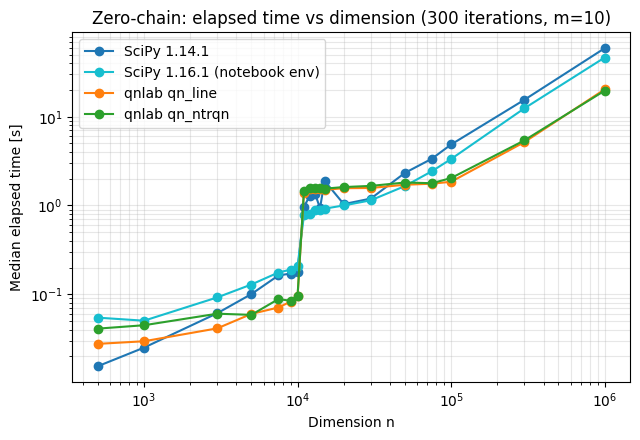

In [6]:
dimension_results = benchmark(
    dimension_cases(DIMENSION_GRID, DIMENSION_ITERATIONS), repeats=REPEATS
)
dimension_summary = show_dimension_scaling(
    dimension_results,
    (
        f"Zero-chain: elapsed time vs dimension "
        f"({DIMENSION_ITERATIONS} iterations, m={MEMORY})"
    ),
    "experiment1_zero_chain_dimension_scaling.png",
)

## Experiment 2: diagonal quadratic at large dimension


In [7]:
ILL_QUADRATIC_ITERATIONS = 100
ill_quadratic_results = benchmark(
    dimension_cases(DIMENSION_GRID, ILL_QUADRATIC_ITERATIONS),
    repeats=REPEATS,
    problem_factory=IllQuadraticProblem,
)

repeat=1/3, n=500, k=100, m=10, SciPy 1.16.1 (notebook env): 0.052 s
repeat=1/3, n=500, k=100, m=10, qnlab qn_line: 0.017 s
repeat=1/3, n=500, k=100, m=10, qnlab qn_ntrqn: 0.036 s
repeat=1/3, n=1000, k=100, m=10, SciPy 1.16.1 (notebook env): 0.038 s
repeat=1/3, n=1000, k=100, m=10, qnlab qn_line: 0.034 s
repeat=1/3, n=1000, k=100, m=10, qnlab qn_ntrqn: 0.020 s
repeat=1/3, n=3000, k=100, m=10, SciPy 1.16.1 (notebook env): 0.045 s
repeat=1/3, n=3000, k=100, m=10, qnlab qn_line: 0.022 s
repeat=1/3, n=3000, k=100, m=10, qnlab qn_ntrqn: 0.022 s
repeat=1/3, n=5000, k=100, m=10, SciPy 1.16.1 (notebook env): 0.106 s
repeat=1/3, n=5000, k=100, m=10, qnlab qn_line: 0.038 s
repeat=1/3, n=5000, k=100, m=10, qnlab qn_ntrqn: 0.017 s
repeat=1/3, n=7500, k=100, m=10, SciPy 1.16.1 (notebook env): 0.110 s
repeat=1/3, n=7500, k=100, m=10, qnlab qn_line: 0.036 s
repeat=1/3, n=7500, k=100, m=10, qnlab qn_ntrqn: 0.022 s
repeat=1/3, n=9000, k=100, m=10, SciPy 1.16.1 (notebook env): 0.058 s
repeat=1/3, n=9000

,solver,dimension,median_seconds,min_seconds,max_seconds,median_function_calls,median_gradient_calls,median_objective
0,SciPy 1.14.1,500,0.004986,0.004424,0.007542,104.0,104.0,0.000001
1,SciPy 1.14.1,1000,0.006940,0.006503,0.009740,106.0,106.0,0.000819
2,SciPy 1.14.1,3000,0.015584,0.015272,0.015900,104.0,104.0,0.084570
3,SciPy 1.14.1,5000,0.029788,0.027659,0.030031,106.0,106.0,0.298200
4,SciPy 1.14.1,7500,0.039939,0.039822,0.042062,104.0,104.0,0.742949
...,...,...,...,...,...,...,...,...
71,qnlab qn_ntrqn,50000,0.530130,0.499803,0.557417,102.0,101.0,34.320955
72,qnlab qn_ntrqn,75000,0.561761,0.559408,0.589690,102.0,101.0,82.200479
73,qnlab qn_ntrqn,100000,0.769652,0.678254,1.091537,104.0,101.0,137.514936
74,qnlab qn_ntrqn,300000,1.752855,1.623356,2.350460,104.0,101.0,1263.885397


Saved c:\Users\hirok\Documents\University\Research\qnlab\doc\SciPy\experiment2_diagonal_quadratic_dimension_scaling.png


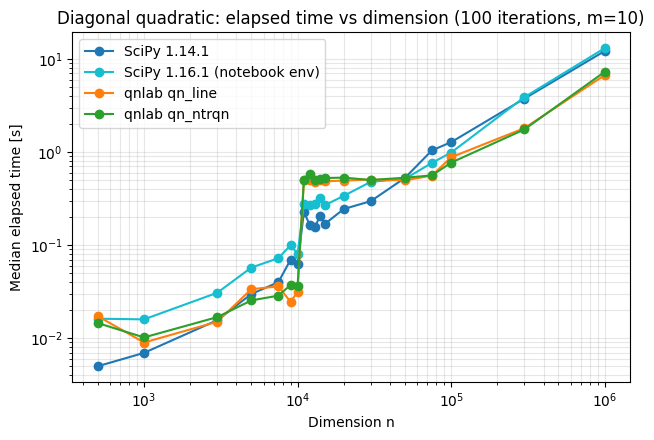

In [8]:
ill_quadratic_summary = show_dimension_scaling(
    ill_quadratic_results,
    (
        f"Diagonal quadratic: elapsed time vs dimension "
        f"({ILL_QUADRATIC_ITERATIONS} iterations, m={MEMORY})"
    ),
    "experiment2_diagonal_quadratic_dimension_scaling.png",
)

## Experiment 3: L-BFGS memory $m=3$ versus $m=10$


In [9]:
LOW_MEMORY = 3
low_memory_results = benchmark(
    dimension_cases(DIMENSION_GRID, ILL_QUADRATIC_ITERATIONS),
    repeats=REPEATS,
    problem_factory=IllQuadraticProblem,
    memory=LOW_MEMORY,
)
memory_results = pd.concat(
    [
        low_memory_results.assign(memory=LOW_MEMORY),
        ill_quadratic_results.assign(memory=MEMORY),
    ],
    ignore_index=True,
)

repeat=1/3, n=500, k=100, m=3, SciPy 1.16.1 (notebook env): 0.012 s
repeat=1/3, n=500, k=100, m=3, qnlab qn_line: 0.014 s
repeat=1/3, n=500, k=100, m=3, qnlab qn_ntrqn: 0.022 s
repeat=1/3, n=1000, k=100, m=3, SciPy 1.16.1 (notebook env): 0.017 s
repeat=1/3, n=1000, k=100, m=3, qnlab qn_line: 0.007 s
repeat=1/3, n=1000, k=100, m=3, qnlab qn_ntrqn: 0.008 s
repeat=1/3, n=3000, k=100, m=3, SciPy 1.16.1 (notebook env): 0.023 s
repeat=1/3, n=3000, k=100, m=3, qnlab qn_line: 0.009 s
repeat=1/3, n=3000, k=100, m=3, qnlab qn_ntrqn: 0.009 s
repeat=1/3, n=5000, k=100, m=3, SciPy 1.16.1 (notebook env): 0.020 s
repeat=1/3, n=5000, k=100, m=3, qnlab qn_line: 0.010 s
repeat=1/3, n=5000, k=100, m=3, qnlab qn_ntrqn: 0.011 s
repeat=1/3, n=7500, k=100, m=3, SciPy 1.16.1 (notebook env): 0.026 s
repeat=1/3, n=7500, k=100, m=3, qnlab qn_line: 0.012 s
repeat=1/3, n=7500, k=100, m=3, qnlab qn_ntrqn: 0.013 s
repeat=1/3, n=9000, k=100, m=3, SciPy 1.16.1 (notebook env): 0.031 s
repeat=1/3, n=9000, k=100, m=3, qn

,solver,memory,dimension,median_seconds,min_seconds,max_seconds,median_function_calls,median_gradient_calls,median_objective
0,SciPy 1.14.1,3,500,0.007252,0.005063,0.007359,109.0,109.0,0.000033
1,SciPy 1.14.1,3,1000,0.005191,0.004708,0.007559,110.0,110.0,0.002761
2,SciPy 1.14.1,3,3000,0.007533,0.007470,0.013423,105.0,105.0,0.138967
3,SciPy 1.14.1,3,5000,0.012935,0.011624,0.021115,107.0,107.0,0.377803
4,SciPy 1.14.1,3,7500,0.017852,0.017118,0.021626,106.0,106.0,1.246183
...,...,...,...,...,...,...,...,...,...
147,qnlab qn_ntrqn,10,50000,0.530130,0.499803,0.557417,102.0,101.0,34.320955
148,qnlab qn_ntrqn,10,75000,0.561761,0.559408,0.589690,102.0,101.0,82.200479
149,qnlab qn_ntrqn,10,100000,0.769652,0.678254,1.091537,104.0,101.0,137.514936
150,qnlab qn_ntrqn,10,300000,1.752855,1.623356,2.350460,104.0,101.0,1263.885397


Saved c:\Users\hirok\Documents\University\Research\qnlab\doc\SciPy\experiment3_lbfgs_memory_comparison.png


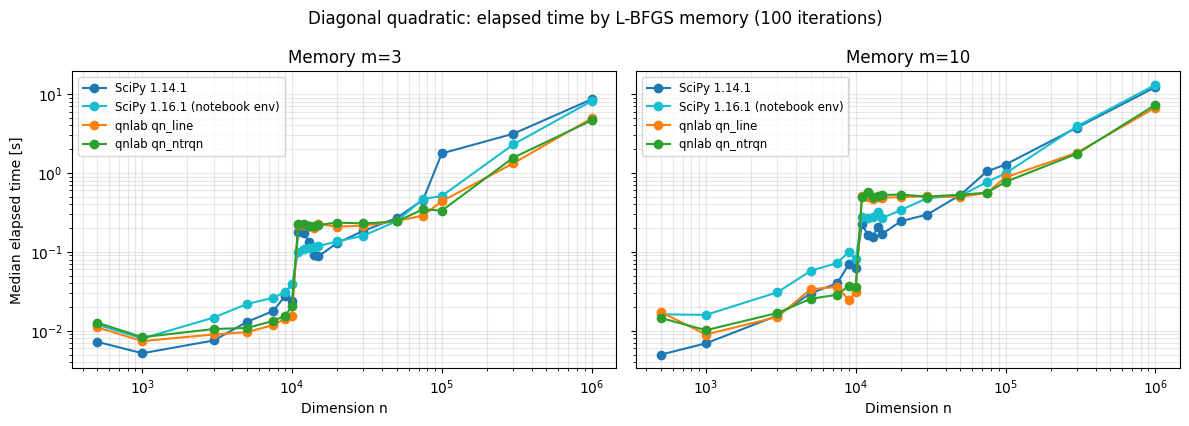

In [10]:
memory_summary = show_dimension_facets(
    memory_results,
    "memory",
    (LOW_MEMORY, MEMORY),
    (f"Memory m={LOW_MEMORY}", f"Memory m={MEMORY}"),
    (
        f"Diagonal quadratic: elapsed time by L-BFGS memory "
        f"({ILL_QUADRATIC_ITERATIONS} iterations)"
    ),
    "experiment3_lbfgs_memory_comparison.png",
)

## Experiment 4: effect of BLAS thread count at large dimensions

Motivated by [SciPy issue #23191](https://github.com/scipy/scipy/issues/23191) and [quadprog PR #71](https://github.com/Jebel-Quant/quadprog/pull/71), this experiment compares the default BLAS thread pool with a single BLAS thread.

In [11]:
display(pd.DataFrame(threadpool_info()))
single_thread_results = benchmark(
    dimension_cases(DIMENSION_GRID, ILL_QUADRATIC_ITERATIONS),
    repeats=REPEATS,
    problem_factory=IllQuadraticProblem,
    blas_threads=1,
)

crossover_results = pd.concat(
    [
        ill_quadratic_results.assign(blas_threads="default"),
        single_thread_results.assign(blas_threads="single"),
    ],
    ignore_index=True,
)

,user_api,internal_api,num_threads,prefix,filepath,version,threading_layer,architecture
0,blas,openblas,16,libscipy_openblas,C:\Users\hirok\Documents\University\Research\q...,0.3.29,pthreads,Haswell
1,blas,openblas,16,libscipy_openblas,C:\Users\hirok\Documents\University\Research\q...,0.3.28,pthreads,Haswell


repeat=1/3, n=500, k=100, m=10, SciPy 1.16.1 (notebook env): 0.023 s
repeat=1/3, n=500, k=100, m=10, qnlab qn_line: 0.028 s
repeat=1/3, n=500, k=100, m=10, qnlab qn_ntrqn: 0.030 s
repeat=1/3, n=1000, k=100, m=10, SciPy 1.16.1 (notebook env): 0.019 s
repeat=1/3, n=1000, k=100, m=10, qnlab qn_line: 0.030 s
repeat=1/3, n=1000, k=100, m=10, qnlab qn_ntrqn: 0.017 s
repeat=1/3, n=3000, k=100, m=10, SciPy 1.16.1 (notebook env): 0.024 s
repeat=1/3, n=3000, k=100, m=10, qnlab qn_line: 0.016 s
repeat=1/3, n=3000, k=100, m=10, qnlab qn_ntrqn: 0.020 s
repeat=1/3, n=5000, k=100, m=10, SciPy 1.16.1 (notebook env): 0.037 s
repeat=1/3, n=5000, k=100, m=10, qnlab qn_line: 0.019 s
repeat=1/3, n=5000, k=100, m=10, qnlab qn_ntrqn: 0.020 s
repeat=1/3, n=7500, k=100, m=10, SciPy 1.16.1 (notebook env): 0.047 s
repeat=1/3, n=7500, k=100, m=10, qnlab qn_line: 0.025 s
repeat=1/3, n=7500, k=100, m=10, qnlab qn_ntrqn: 0.025 s
repeat=1/3, n=9000, k=100, m=10, SciPy 1.16.1 (notebook env): 0.051 s
repeat=1/3, n=9000

,solver,blas_threads,dimension,median_seconds,min_seconds,max_seconds,median_function_calls,median_gradient_calls,median_objective
0,SciPy 1.14.1,default,500,0.004986,0.004424,0.007542,104.0,104.0,0.000001
1,SciPy 1.14.1,default,1000,0.006940,0.006503,0.009740,106.0,106.0,0.000819
2,SciPy 1.14.1,default,3000,0.015584,0.015272,0.015900,104.0,104.0,0.084570
3,SciPy 1.14.1,default,5000,0.029788,0.027659,0.030031,106.0,106.0,0.298200
4,SciPy 1.14.1,default,7500,0.039939,0.039822,0.042062,104.0,104.0,0.742949
...,...,...,...,...,...,...,...,...,...
147,qnlab qn_ntrqn,single,50000,0.191140,0.156967,0.212635,102.0,101.0,34.320955
148,qnlab qn_ntrqn,single,75000,0.365018,0.291348,0.434872,102.0,101.0,82.200478
149,qnlab qn_ntrqn,single,100000,0.719194,0.701046,0.752044,104.0,101.0,137.514936
150,qnlab qn_ntrqn,single,300000,2.798991,2.724391,2.862059,104.0,101.0,1263.885398


Saved c:\Users\hirok\Documents\University\Research\qnlab\doc\SciPy\experiment4_blas_thread_comparison.png


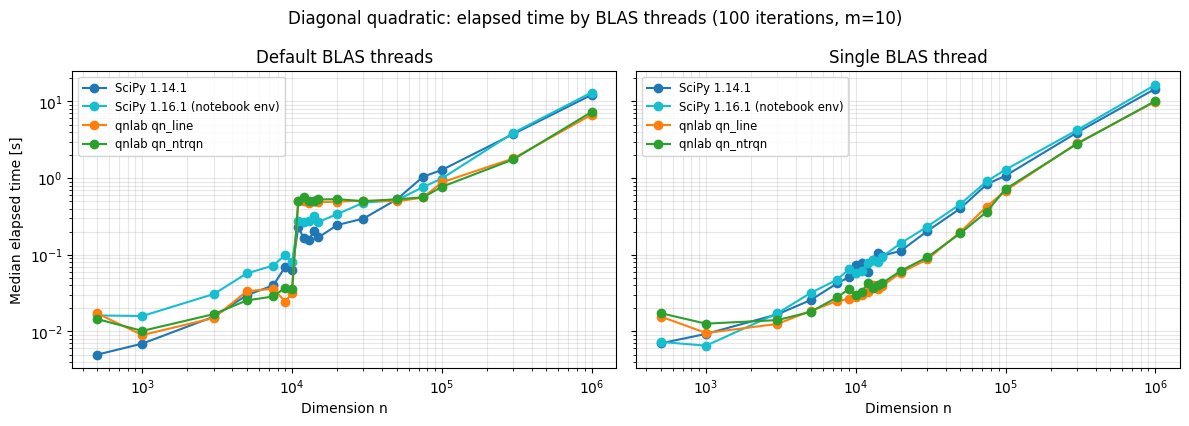

In [12]:
crossover_summary = show_dimension_facets(
    crossover_results,
    "blas_threads",
    ("default", "single"),
    ("Default BLAS threads", "Single BLAS thread"),
    (
        f"Diagonal quadratic: elapsed time by BLAS threads "
        f"({ILL_QUADRATIC_ITERATIONS} iterations, m={MEMORY})"
    ),
    "experiment4_blas_thread_comparison.png",
)